In [1]:
%load_ext autoreload
%autoreload 2
import os
os.environ["MUJOCO_GL"] = "egl"

In [2]:
import numpy as np

In [23]:
import argparse
import pathlib
import sys

import numpy as np
import torch
#from omegaconf import OmegaConf

import sys
from tqdm import tqdm
import matplotlib.pyplot as plt

sys.path.append("/home/hgf_hmgu/hgf_gib4562/tdmpc2/dreamerv3-torch")
import dreamer as dreamer_main
import models as dreamer_models
import tools as dreamer_tools
import ruamel.yaml as yaml
from tqdm import tqdm
from itertools import product
from sklearn.metrics import r2_score

In [4]:
def _parse_dreamer_config(configs_path, config_names, overrides):
    configs = yaml.safe_load(pathlib.Path(configs_path).read_text())

    def recursive_update(base, update):
        for key, value in update.items():
            if isinstance(value, dict) and key in base:
                recursive_update(base[key], value)
            else:
                base[key] = value

    name_list = ["defaults", *config_names] if config_names else ["defaults"]
    defaults = {}
    for name in name_list:
        recursive_update(defaults, configs[name])

    overrides_map = {}
    for item in overrides:
        if item.startswith("--"):
            item = item[2:]
        if "=" in item:
            key, value = item.split("=", 1)
            if key not in defaults:
                raise KeyError(f"Unknown config key '{key}' in override.")
            cast = dreamer_tools.args_type(defaults[key])
            overrides_map[key] = cast(value)
        else:
            if item not in defaults:
                raise KeyError(f"Unknown config key '{item}' in override.")
            overrides_map[item] = True

    merged = {**defaults, **overrides_map}
    return argparse.Namespace(**merged)

## Create environment

In [5]:
# Real Dreamer obs_batch from DMC cartpole_swingup (vision + proprio)
import numpy as np
import torch

from envs import dmc
import envs.wrappers as wrappers

# Create env (matches Dreamer DMC defaults)
env = dmc.DeepMindControl("cartpole_swingup",
                          action_repeat=2,
                          size=(64, 64),
                          seed=0)
env = wrappers.NormalizeActions(env)

/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/dreamerv3/lib/python3.11/site-packages/gym/spaces/box.py:78: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


In [9]:
def load_dreamer_world_model(
        configs_path="/home/hgf_hmgu/hgf_gib4562/tdmpc2/dreamerv3-torch/configs.yaml",
        config_names=["dmc_vision"],
        overrides=["task=dmc_cartpole_swingup"],
        ckpt_path='/home/hgf_hmgu/hgf_gib4562/tdmpc2/dreamerv3-torch/logdir/dmc_cartpole_swingup_pixel/latest.pt',
        env=None,
        device='cuda:0'):
    cfg = _parse_dreamer_config(
        configs_path,
        config_names,
        overrides,
    )
    cfg.num_actions = 1
    assert env is not None, "You must provide an environment with a valid observation_space."
    wm = dreamer_models.WorldModel(env.observation_space,
                                   None,
                                   step=0,
                                   config=cfg).to(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    agent_state = ckpt.get("agent_state_dict", ckpt)

    # Handle torch.compile() prefix - strip '_orig_mod.' from keys
    agent_state = {
        k.replace('_orig_mod.', ''): v for k, v in agent_state.items()
    }

    wm_state = {
        k[len("_wm."):]: v
        for k, v in agent_state.items()
        if k.startswith("_wm.")
    }
    wm.load_state_dict(wm_state, strict=True)
    wm.eval()
    return wm, cfg

In [10]:
# Example usage (you must provide 'env'):
wm_state, cfg_state = load_dreamer_world_model(
    configs_path=
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/dreamerv3-torch/configs.yaml",
    config_names=["dmc_proprio"],
    overrides=["task=dmc_cartpole_swingup"],
    ckpt_path=
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/dreamerv3-torch/logdir/dmc_cartpole_swingup_srun/latest.pt',
    env=env)

# Example usage (you must provide 'env'):
wm_pixel, cfg_pixel = load_dreamer_world_model(
    configs_path=
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/dreamerv3-torch/configs.yaml",
    config_names=["dmc_vision"],
    overrides=["task=dmc_cartpole_swingup"],
    ckpt_path=
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/dreamerv3-torch/logdir/dmc_cartpole_swingup_pixel/latest.pt',
    env=env)

Encoder CNN shapes: {}
Encoder MLP shapes: {'position': (3,), 'velocity': (2,)}
Decoder CNN shapes: {}
Decoder MLP shapes: {'position': (3,), 'velocity': (2,)}
Optimizer model_opt has 16428293 variables.


/scratch/slurm_tmpdir/job_1611114/ipykernel_4079475/2646194734.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


Encoder CNN shapes: {'image': (64, 64, 3)}
Encoder MLP shapes: {}
Decoder CNN shapes: {'image': (64, 64, 3)}
Decoder MLP shapes: {}
Optimizer model_opt has 15685251 variables.


In [74]:
wm_pixel.eval()
wm_state.eval()

WorldModel(
  (encoder): MultiEncoder(
    (_mlp): MLP(
      (layers): Sequential(
        (Encoder_linear0): Linear(in_features=5, out_features=1024, bias=False)
        (Encoder_norm0): LayerNorm((1024,), eps=0.001, elementwise_affine=True)
        (Encoder_act0): SiLU()
        (Encoder_linear1): Linear(in_features=1024, out_features=1024, bias=False)
        (Encoder_norm1): LayerNorm((1024,), eps=0.001, elementwise_affine=True)
        (Encoder_act1): SiLU()
        (Encoder_linear2): Linear(in_features=1024, out_features=1024, bias=False)
        (Encoder_norm2): LayerNorm((1024,), eps=0.001, elementwise_affine=True)
        (Encoder_act2): SiLU()
        (Encoder_linear3): Linear(in_features=1024, out_features=1024, bias=False)
        (Encoder_norm3): LayerNorm((1024,), eps=0.001, elementwise_affine=True)
        (Encoder_act3): SiLU()
        (Encoder_linear4): Linear(in_features=1024, out_features=1024, bias=False)
        (Encoder_norm4): LayerNorm((1024,), eps=0.001, eleme

## Rollouts

In [40]:
# Latent rollout + reconstruction from a start observation and action sequence
import torch


def latent_rollout_and_reconstruction(wm,
                                      obs_batch,
                                      actions,
                                      steps=5,
                                      use_soft_stoch=False,
                                      deterministic=False,
                                      verbose=False,
                                      is_rgb=True):
    """
    Perform latent rollout and reconstruction from a start observation and action sequence.
    
    Args:
        wm: The world model object.
        obs_batch: Batch of observations.
        actions: Action sequence tensor of shape (B, T, action_dim).
        steps: Number of rollout steps. Default: 5
        use_soft_stoch: If True, use softmax probabilities for 'stoch' in discrete latent. Default: False
        deterministic: If True, use mode sampling in img_step. Default: False

    Returns:
        feats: Tensor of shape (B, steps+1, feat_dim)
        recons: Dict of tensors, each of shape (B, steps+1, ...)
    """
    data = wm.preprocess(obs_batch)
    embed = wm.encoder(data)
    # post, _ = wm.dynamics.observe(embed=embed,
    #                               action=actions[:, 0],
    #                               is_first=torch.zeros((1, 1)).to('cuda'),
    #                               sample=False)

    post, _ = wm.dynamics.obs_step(prev_state=None,
                                   prev_action=actions[:, 0],
                                   embed=embed[:, 0],
                                   is_first=torch.zeros((1, 1)).to('cuda'),
                                   sample=False)
    state = post

    feats = []
    recons = {}

    def _feat_and_recon(cur_state):
        if use_soft_stoch and "logit" in cur_state:
            probs = torch.softmax(cur_state["logit"], dim=-1)
            cur_state = {**cur_state, "stoch": probs}
        feat = wm.dynamics.get_feat(cur_state)
        if is_rgb:
            feat = feat.unsqueeze(1)

        dists = wm.heads["decoder"](feat)
        if is_rgb:
            recon = {k: v.mode().squeeze(1) for k, v in dists.items()}
        else:
            recon = {k: v.mode() for k, v in dists.items()}
        return feat, recon

    feat0, recon0 = _feat_and_recon(state)
    feats.append(feat0)
    for k, v in recon0.items():
        recons.setdefault(k, []).append(v)

    for t in range(1, steps):
        old_deter = state["deter"].clone()
        state = wm.dynamics.img_step(state,
                                     actions[:, t],
                                     sample=not deterministic)
        if verbose:
            print(
                f"Step {t}: deter changed by {(state['deter'] - old_deter).abs().mean().item()}"
            )
        feat_t, recon_t = _feat_and_recon(state)
        feats.append(feat_t)
        for k, v in recon_t.items():
            recons.setdefault(k, []).append(v)

    feats = torch.stack(feats, dim=1)  # (B, steps, feat_dim)
    recons = {k: torch.stack(v, dim=1) for k, v in recons.items()}

    return feats, recons


def get_feats_all(wm, obs_batch):

    with torch.no_grad():
        data = wm.preprocess(obs_batch)
        embed = wm.encoder(data)
        post, _ = wm.dynamics.observe(embed, data["action"], data["is_first"])
        feats = wm.dynamics.get_feat(post)  # (B, T, feat_dim)

        probs = torch.softmax(post["logit"], dim=-1)  # (B,T,stoch,discrete)
        state_soft = {**post, "stoch": probs}
        feat_soft = wm.dynamics.get_feat(state_soft)
    return feats, feat_soft

In [12]:
import pickle

with open(
        "/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/data_generation/data_passive.pkl",
        "rb") as f:
    data_passive = pickle.load(f)

path_off_policy = "/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/data_generation/data_off_policy.pkl"
with open(path_off_policy, 'rb') as f:
    data_off_policy = pickle.load(f)

In [14]:
data_passive.keys(), data_off_policy.keys()

(dict_keys(['obs_states', 'obs_pixels_dreamer', 'obs_pixels_tdmpc2', 'actions', 'rewards']),
 dict_keys(['obs_states', 'obs_pixels_dreamer', 'obs_pixels_tdmpc2', 'actions', 'rewards']))

In [54]:
def build_obs_episodic(
    obs_states,
    obs_pixels,
    actions,
    steps_to_run=50,
    episode_length=500,
):
    """
    Given arrays of obs_states and obs_pixels (both shape [N, ...]), split into episodic structure.

    Args:
        obs_states: np.array, (N, state_dim)
        obs_pixels: np.array, (N, H, W, C)
        steps_to_run: int, number of steps per episode

    Returns:
        obs_autonomous_episodic: list of episode dicts
        obs_autonomous_batch_stacked: dict of stacked arrays for batch usage
    """
    # Split into episodes
    obs_pixels_list = np.array_split(obs_pixels,
                                     obs_pixels.shape[0] // episode_length)
    obs_states_list = np.array_split(obs_states,
                                     obs_states.shape[0] // episode_length)

    obs_autonomous_episodic = []

    for ob_states, ob_pixels in zip(obs_states_list, obs_pixels_list):
        episode = {}
        episode['position'] = ob_states[:steps_to_run, :3][None, ...]
        episode['velocity'] = ob_states[:steps_to_run, 3:][None, ...]
        episode['action'] = actions[:steps_to_run][None, ...]
        episode['is_first'] = np.zeros((1, steps_to_run, 1))
        episode['is_first'][:, 0, :] = 1  # Set only timestep 0 to is_first=1
        episode['is_terminal'] = np.zeros(steps_to_run).reshape(-1, 1)[None,
                                                                       ...]
        episode['image'] = ob_pixels[:steps_to_run, ...][None, ...]
        obs_autonomous_episodic.append(episode)

    # Collate into batch structure
    # obs_autonomous_batch_stacked = {
    #     'position':
    #         np.concatenate([ep['position'] for ep in obs_autonomous_episodic],
    #                        axis=1),  # (num_episodes, episode_length, 3)
    #     'velocity':
    #         np.concatenate([ep['velocity'] for ep in obs_autonomous_episodic],
    #                        axis=1),
    #     'action':
    #         np.concatenate([ep['action'] for ep in obs_autonomous_episodic],
    #                        axis=1),
    #     'is_first':
    #         np.concatenate([ep['is_first'] for ep in obs_autonomous_episodic],
    #                        axis=1),
    #     'is_terminal':
    #         np.concatenate(
    #             [ep['is_terminal'] for ep in obs_autonomous_episodic], axis=1),
    #     'image':
    #         np.concatenate([ep['image'] for ep in obs_autonomous_episodic],
    #                        axis=1)
    # }
    return obs_autonomous_episodic  #, obs_autonomous_batch_stacked


In [83]:
obs_passive = build_obs_episodic(
    data_passive['obs_states'],
    data_passive['obs_pixels_dreamer'],
    data_passive['actions'],
    episode_length=100,  # the data is created with episode length 100
    steps_to_run=50,
)

obs_off_policy = build_obs_episodic(
    data_off_policy['obs_states'],
    data_off_policy['obs_pixels_dreamer'],
    data_off_policy['actions'],
    episode_length=100,  # the data is created with episode length 100
    steps_to_run=50,
)


In [84]:
obs_passive[0]['position'].shape, obs_passive[0]['velocity'].shape, obs_passive[
    0]['action'].shape, obs_passive[0]['is_first'].shape, obs_passive[0][
        'is_terminal'].shape, obs_passive[0]['image'].shape

((1, 50, 3),
 (1, 50, 2),
 (1, 50, 1),
 (1, 50, 1),
 (1, 50, 1),
 (1, 50, 64, 64, 3))

In [85]:
obs_off_policy[0]['position'].shape, obs_off_policy[0][
    'velocity'].shape, obs_off_policy[0]['action'].shape, obs_off_policy[0][
        'is_first'].shape, obs_off_policy[0][
            'is_terminal'].shape, obs_off_policy[0]['image'].shape

((1, 50, 3),
 (1, 50, 2),
 (1, 50, 1),
 (1, 50, 1),
 (1, 50, 1),
 (1, 50, 64, 64, 3))

## Analysis of the dynamics

In [86]:
def evaluate_rollout(wm, obs_true_batch, steps_to_run=100):
    """
    Analyze Dreamer dynamics: run latent rollout, compute reconstruction and R2/variance/error metrics.

    Args:
        wm: World model.
        obs_true_batch: Dict containing the ground truth observations for 'position' and 'velocity'.
        steps_to_run: Number of rollout steps.

    Returns:
        result: Dict with various arrays of true/predicted latent/obs, errors, R2, variances, etc.
    """
    obs_true = np.concatenate([
        obs_true_batch['position'].squeeze(),
        obs_true_batch['velocity'].squeeze()
    ],
                              axis=1)
    _, z_true = get_feats_all(wm, obs_true_batch)
    z_true = z_true.detach().cpu().numpy().squeeze()
    z_true = z_true[:steps_to_run, :]
    z_predicted, obs_reconstructed = latent_rollout_and_reconstruction(
        wm,
        obs_true_batch,
        torch.from_numpy(obs_true_batch['action']).to('cuda'),
        steps=steps_to_run,
        use_soft_stoch=True,
        deterministic=True)
    z_predicted = z_predicted.detach().cpu().numpy().squeeze()

    errors_latent = (abs(z_true - z_predicted)).mean(1)
    error_latent_per_dim = [
        (abs(z_true[:, i] - z_predicted[:, i])).mean() for i in range(512)
    ]
    r2_latent = r2_score(z_true, z_predicted)
    r2_latent_per_dim = [
        r2_score(z_true[:, i], z_predicted[:, i]) for i in range(512)
    ]

    r2_latent_per_time = [
        r2_score(z_true[t, :], z_predicted[t, :]) for t in range(steps_to_run)
    ]

    r2_latent_per_time_stoch = [
        r2_score(z_true[t, :1024], z_predicted[t, :1024])
        for t in range(steps_to_run)
    ]

    r2_latent_per_time_deter = [
        r2_score(z_true[t, 1024:], z_predicted[t, 1024:])
        for t in range(steps_to_run)
    ]

    variance_z_true_per_dim = np.var(z_true, axis=0)
    variance_z_predicted_per_dim = np.var(z_predicted, axis=0)
    variance_obs_true_per_dim = np.var(obs_true, axis=0)

    result = {
        'obs_true': obs_true,
        'obs_reconstructed': obs_reconstructed,
        'z_true': z_true,
        'z_predicted': z_predicted,
        'errors_latent': errors_latent,
        'error_latent_per_dim': error_latent_per_dim,
        'r2_latent': r2_latent,
        'r2_latent_per_dim': r2_latent_per_dim,
        'r2_latent_per_time': r2_latent_per_time,
        'r2_latent_per_time_stoch': r2_latent_per_time_stoch,
        'r2_latent_per_time_deter': r2_latent_per_time_deter,
        'variance_z_true_per_dim': variance_z_true_per_dim,
        'variance_z_predicted_per_dim': variance_z_predicted_per_dim,
        'variance_obs_true_per_dim': variance_obs_true_per_dim,
    }
    return result

In [94]:
def run_evaluate_rollouts(wm, obs_batch, steps_to_run=50, num_episodes=50):
    results = []
    for episode in tqdm(obs_batch[:num_episodes]):
        results.append(evaluate_rollout(wm, episode, steps_to_run=steps_to_run))
    return results


In [95]:
results_passive_state = run_evaluate_rollouts(wm_state,
                                              obs_passive,
                                              steps_to_run=50,
                                              num_episodes=100)
results_off_policy_state = run_evaluate_rollouts(wm_state,
                                                 obs_off_policy,
                                                 steps_to_run=50,
                                                 num_episodes=100)

results_passive_pixel = run_evaluate_rollouts(wm_pixel,
                                              obs_passive,
                                              steps_to_run=50,
                                              num_episodes=100)
results_off_policy_pixel = run_evaluate_rollouts(wm_pixel,
                                                 obs_off_policy,
                                                 steps_to_run=50,
                                                 num_episodes=100)


100%|██████████| 100/100 [02:34<00:00,  1.54s/it]


In [96]:
def get_bootstrap_ci(
    results,
    metric_key='r2_latent_per_time',
    n_bootstrap=1000,
    confidence=0.95,
):
    """
    Plot mean with bootstrap confidence interval.
    """
    data = np.array([r[metric_key] for r in results])
    n_rollouts, n_timesteps = data.shape

    # Bootstrap resampling
    bootstrap_means = np.zeros((n_bootstrap, n_timesteps))
    for i in range(n_bootstrap):
        # Sample with replacement
        indices = np.random.choice(n_rollouts, size=n_rollouts, replace=True)
        bootstrap_means[i] = np.mean(data[indices], axis=0)

    # Compute percentiles
    alpha = (1 - confidence) / 2
    ci_lower = np.percentile(bootstrap_means, alpha * 100, axis=0)
    ci_upper = np.percentile(bootstrap_means, (1 - alpha) * 100, axis=0)
    mean = np.mean(data, axis=0)

    return mean, ci_lower, ci_upper

In [97]:
# For 'stoch', 'deter', and 'normal'

# --- r2_latent_per_time_stoch ---
mean_state_passive_stoch, ci_lower_state_passive_stoch, ci_upper_state_passive_stoch = get_bootstrap_ci(
    results_passive_state, metric_key='r2_latent_per_time_stoch')
mean_state_offpolicy_stoch, ci_lower_state_offpolicy_stoch, ci_upper_state_offpolicy_stoch = get_bootstrap_ci(
    results_off_policy_state, metric_key='r2_latent_per_time_stoch')
mean_rgb_passive_stoch, ci_lower_rgb_passive_stoch, ci_upper_rgb_passive_stoch = get_bootstrap_ci(
    results_passive_pixel, metric_key='r2_latent_per_time_stoch')
mean_rgb_offpolicy_stoch, ci_lower_rgb_offpolicy_stoch, ci_upper_rgb_offpolicy_stoch = get_bootstrap_ci(
    results_off_policy_pixel, metric_key='r2_latent_per_time_stoch')

# --- r2_latent_per_time_deter ---
mean_state_passive_deter, ci_lower_state_passive_deter, ci_upper_state_passive_deter = get_bootstrap_ci(
    results_passive_state, metric_key='r2_latent_per_time_deter')
mean_state_offpolicy_deter, ci_lower_state_offpolicy_deter, ci_upper_state_offpolicy_deter = get_bootstrap_ci(
    results_off_policy_state, metric_key='r2_latent_per_time_deter')
mean_rgb_passive_deter, ci_lower_rgb_passive_deter, ci_upper_rgb_passive_deter = get_bootstrap_ci(
    results_passive_pixel, metric_key='r2_latent_per_time_deter')
mean_rgb_offpolicy_deter, ci_lower_rgb_offpolicy_deter, ci_upper_rgb_offpolicy_deter = get_bootstrap_ci(
    results_off_policy_pixel, metric_key='r2_latent_per_time_deter')

# --- r2_latent_per_time (normal) ---
mean_state_passive, ci_lower_state_passive, ci_upper_state_passive = get_bootstrap_ci(
    results_passive_state, metric_key='r2_latent_per_time')
mean_state_offpolicy, ci_lower_state_offpolicy, ci_upper_state_offpolicy = get_bootstrap_ci(
    results_off_policy_state, metric_key='r2_latent_per_time')
mean_rgb_passive, ci_lower_rgb_passive, ci_upper_rgb_passive = get_bootstrap_ci(
    results_passive_pixel, metric_key='r2_latent_per_time')
mean_rgb_offpolicy, ci_lower_rgb_offpolicy, ci_upper_rgb_offpolicy = get_bootstrap_ci(
    results_off_policy_pixel, metric_key='r2_latent_per_time')

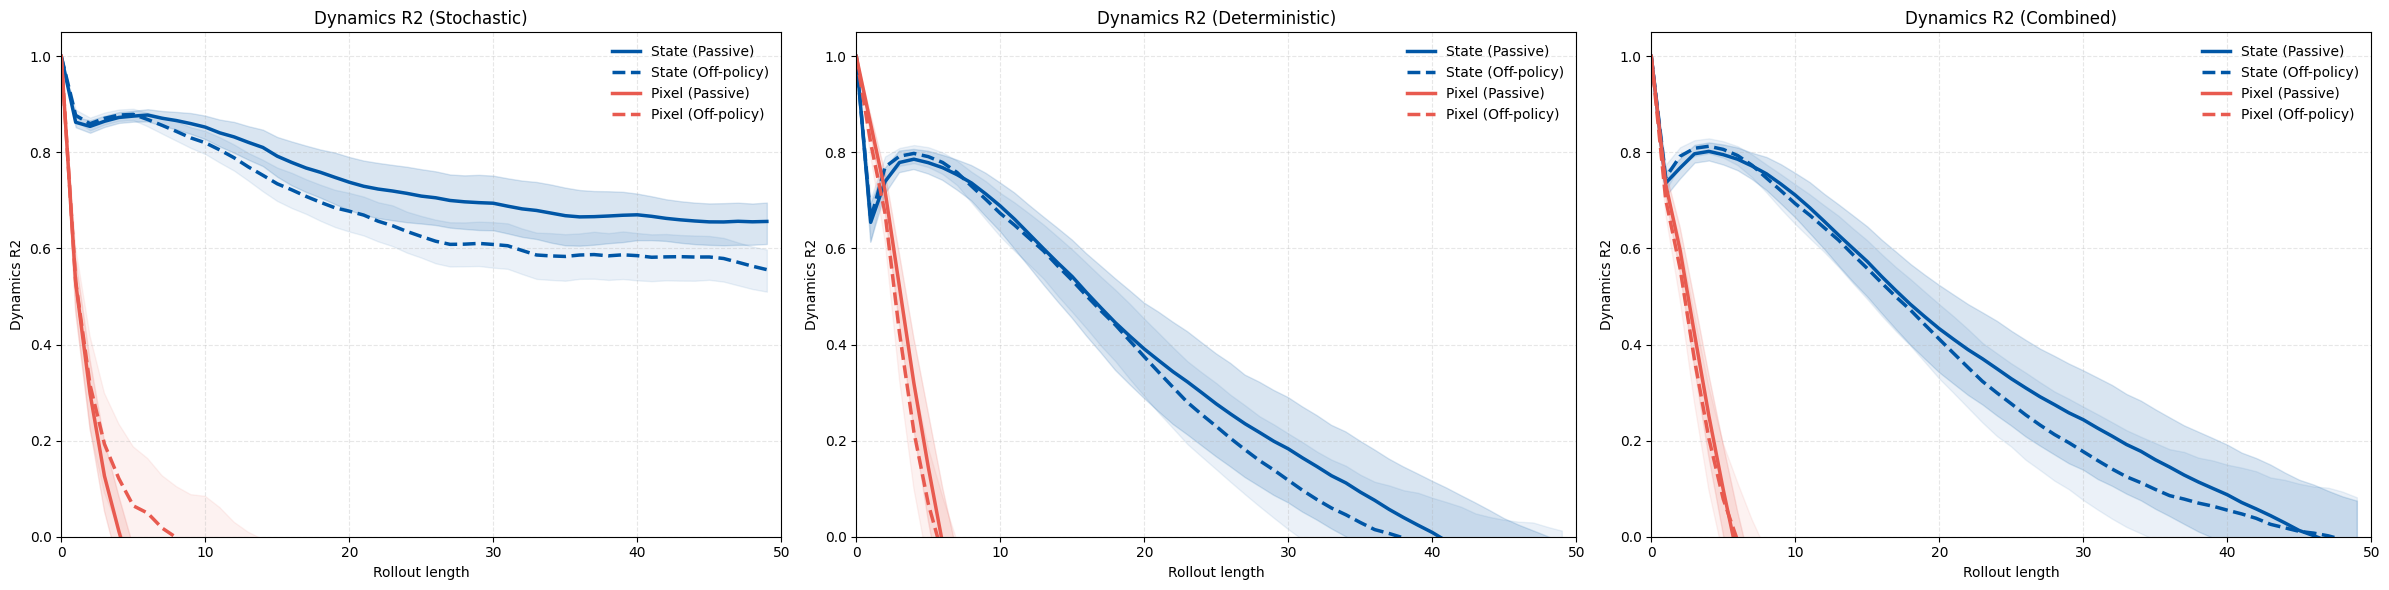

In [101]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# Colors: state = blue, rgb pixel = red
state_color = "#0056A6"
rgb_color = "#E85A4F"

# Create three subplots for stoch, deter, and normal
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Data for each subplot
plot_data = [
    ("Stochastic", mean_state_passive_stoch, ci_lower_state_passive_stoch,
     ci_upper_state_passive_stoch, mean_state_offpolicy_stoch,
     ci_lower_state_offpolicy_stoch, ci_upper_state_offpolicy_stoch,
     mean_rgb_passive_stoch, ci_lower_rgb_passive_stoch,
     ci_upper_rgb_passive_stoch, mean_rgb_offpolicy_stoch,
     ci_lower_rgb_offpolicy_stoch, ci_upper_rgb_offpolicy_stoch),
    ("Deterministic", mean_state_passive_deter, ci_lower_state_passive_deter,
     ci_upper_state_passive_deter, mean_state_offpolicy_deter,
     ci_lower_state_offpolicy_deter, ci_upper_state_offpolicy_deter,
     mean_rgb_passive_deter, ci_lower_rgb_passive_deter,
     ci_upper_rgb_passive_deter, mean_rgb_offpolicy_deter,
     ci_lower_rgb_offpolicy_deter, ci_upper_rgb_offpolicy_deter),
    ("Combined", mean_state_passive, ci_lower_state_passive,
     ci_upper_state_passive, mean_state_offpolicy, ci_lower_state_offpolicy,
     ci_upper_state_offpolicy, mean_rgb_passive, ci_lower_rgb_passive,
     ci_upper_rgb_passive, mean_rgb_offpolicy, ci_lower_rgb_offpolicy,
     ci_upper_rgb_offpolicy)
]

for ax, (title, state_pass_mean, state_pass_lower, state_pass_upper,
         state_off_mean, state_off_lower, state_off_upper, rgb_pass_mean,
         rgb_pass_lower, rgb_pass_upper, rgb_off_mean, rgb_off_lower,
         rgb_off_upper) in zip(axes, plot_data):

    timesteps = np.arange(len(state_pass_mean))

    # Plot state passive
    ax.plot(timesteps,
            state_pass_mean,
            color=state_color,
            lw=2.5,
            label="State (Passive)",
            linestyle='-')
    ax.fill_between(timesteps,
                    state_pass_lower,
                    state_pass_upper,
                    color=state_color,
                    alpha=0.15)

    # Plot state off-policy
    ax.plot(timesteps,
            state_off_mean,
            color=state_color,
            lw=2.5,
            label="State (Off-policy)",
            linestyle='--')
    ax.fill_between(timesteps,
                    state_off_lower,
                    state_off_upper,
                    color=state_color,
                    alpha=0.08)

    # Plot RGB passive
    ax.plot(timesteps,
            rgb_pass_mean,
            color=rgb_color,
            lw=2.5,
            label="Pixel (Passive)",
            linestyle='-')
    ax.fill_between(timesteps,
                    rgb_pass_lower,
                    rgb_pass_upper,
                    color=rgb_color,
                    alpha=0.15)

    # Plot RGB off-policy
    ax.plot(timesteps,
            rgb_off_mean,
            color=rgb_color,
            lw=2.5,
            label="Pixel (Off-policy)",
            linestyle='--')
    ax.fill_between(timesteps,
                    rgb_off_lower,
                    rgb_off_upper,
                    color=rgb_color,
                    alpha=0.08)

    # Configure axes
    ax.set_xlabel("Rollout length")
    ax.set_ylabel("Dynamics R2")
    ax.set_title(f"Dynamics R2 ({title})")
    ax.set_ylim(0, 1.05)
    ax.set_xlim([timesteps[0], timesteps[-1]])
    ax.grid(ls="--", alpha=0.3, zorder=0)
    ax.legend(frameon=False)
    ax.set_xticks(np.arange(timesteps[0], timesteps[-1] + 2, 10))

plt.tight_layout()
plt.show()